In [ ]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# Kolmogorov–Smirnov Tests — THS Survey vs Cellular vs Hybrid

A two-sample KS test compares two **one-dimensional distributions**: its statistic `D = max |F_A(x) − F_B(x)|` is the largest gap between the two cumulative distributions, and it says where that gap sits. An OD matrix is not one-dimensional, so the test is applied to the distributions an OD matrix implies, each weighted by trips:

| # | Test | Distribution compared | Reference |
|---|---|---|---|
| KS0 | Distance-proxy calibration | survey trip lengths: reported `TrvlDist` vs centroid distance of the same trips | — |
| KS1 | Trip length distribution (TLD) | share of trips by centroid distance, all cells | survey day 1 vs day 2; household bootstrap of the survey |
| KS2 | TLD without the diagonal | same, excluding intra-TAZ cells, then excluding intra-cellular-zone cells | day 1 vs day 2 |
| KS3 | Per-origin TLD | each origin superzone's trips by distance | day 1 vs day 2 |
| KS4 | Corridor TLD | TLD by corridor class (both ends / one end / neither in the 119 corridor TAZs) | day 1 vs day 2 |
| KS5 | Flow concentration | share of trips carried by cells of a given size (how diffuse the matrix is), SZ and TAZ | day 1 vs day 2 |

Matrices are the same three as in `THS_2017_cosine_GEH_tests.ipynb`: the **THS survey rebuilt from the trips file (survey days 1 and 2)** — the activities file (days 10 / 20) is not read —, the **cellular** AM matrix allocated total-preservingly to study TAZs, and the **primary hybrid**. Distances are straight-line centroid distances from `Input/TAZ_North` (Israel TM grid), with half the nearest-centroid distance as the intra-TAZ length.

**On p-values.** With expanded weights the classical KS p-value is meaningless (it would treat 2 million expanded trips as 2 million observations). Significance is judged instead against the survey's own sampling noise: the `D` of day 1 vs day 2, and a household bootstrap of the survey (resampling households with replacement, 200 replicates) that gives the spread of `D` each survey-based comparison carries.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapefile
from shapely.geometry import shape

rng = np.random.default_rng(42)
BLUE, ORANGE, AQUA, PURPLE = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

OUT = 'Output/ths2017/tests'
os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## 1. Data — the same chain as the cosine / GEH notebook

In [2]:
TRIPS_FILE = 'Input/trips_ths_2017.xlsx'
df = pd.read_excel(TRIPS_FILE)
assert set(df['SurveyDay'].unique()) == {1, 2}, "the trips file must carry survey days 1 and 2 only"
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy()
g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1); d['trip_dep_h'] = g['Dep_h'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h'])
trips = trips[trips['trip_dep_h'].isin([6, 7, 8])]
k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636')
map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']
trips = trips.assign(o1250=trips['origin'].map(map_2636_1250), d1250=trips['actTaz'].map(map_2636_1250))

keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
kn = keys_raw[['TAZ_1270', 'TAZ_NUMBER']].dropna(subset=['TAZ_NUMBER']); kn['TAZ_NUMBER'] = kn['TAZ_NUMBER'].astype(int)
kd = kn.drop_duplicates('TAZ_NUMBER')
cellular = pd.read_csv('Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv')[['fromZone', 'ToZone', 'h6', 'h7', 'h8']]
c = cellular.merge(kd.rename(columns={'TAZ_1270': 'fromZone', 'TAZ_NUMBER': 'fromTaz'}), on='fromZone')
c = c.merge(kd.rename(columns={'TAZ_1270': 'ToZone', 'TAZ_NUMBER': 'ToTaz'}), on='ToZone')
cell_taz_repl = c.groupby(['fromTaz', 'ToTaz'])[['h6', 'h7', 'h8']].sum().sum(axis=1).unstack().fillna(0)
TAZ = cell_taz_repl.index; N = len(TAZ)
out_vol, in_vol = cell_taz_repl.sum(axis=1), cell_taz_repl.sum(axis=0)
north_1250 = sorted(kd[kd['TAZ_NUMBER'].isin(TAZ)]['TAZ_1270'].unique())
z_idx = {z: i for i, z in enumerate(north_1250)}
children = kd[kd['TAZ_NUMBER'].isin(TAZ)].groupby('TAZ_1270')['TAZ_NUMBER'].apply(list)
taz_pos = {t: j for j, t in enumerate(TAZ)}
def alloc_matrix(vol):
    S = np.zeros((len(north_1250), N))
    for z, kids in children.items():
        v = np.array([vol[t] for t in kids], float)
        s = v / v.sum() if v.sum() > 0 else np.full(len(kids), 1 / len(kids))
        for t, sh in zip(kids, s): S[z_idx[z], taz_pos[t]] = sh
    return S
S_o, S_d = alloc_matrix(out_vol), alloc_matrix(in_vol)
tm = trips[trips['o1250'].isin(z_idx) & trips['d1250'].isin(z_idx)].copy()
tm['oi'] = tm['o1250'].map(z_idx); tm['di'] = tm['d1250'].map(z_idx)

def survey_1250(t):
    M = np.zeros((len(north_1250), len(north_1250)))
    np.add.at(M, (t['oi'].values, t['di'].values), t['new_wf'].values)
    return M
S1_1250, S2_1250 = survey_1250(tm[tm['SurveyDay'] == 1]), survey_1250(tm[tm['SurveyDay'] == 2])
S1, S2 = S_o.T @ S1_1250 @ S_d, S_o.T @ S2_1250 @ S_d
SAVG = (S1 + S2) / 2
saved_avg = pd.read_csv('Output/ths2017/study_taz/matrix_avg_ALL_taz.csv', index_col=0); saved_avg.columns = saved_avg.columns.astype(int)
assert np.abs(SAVG - saved_avg.reindex(index=TAZ, columns=TAZ).values).max() / saved_avg.values.max() < 1e-4
print("validation: rebuilt trips-file day-average matches saved matrix_avg_ALL_taz.csv")

cn = cellular[cellular['fromZone'].isin(z_idx) & cellular['ToZone'].isin(z_idx)]
C_1250 = (cn.assign(v=cn[['h6', 'h7', 'h8']].sum(axis=1)).groupby(['fromZone', 'ToZone'])['v'].sum()
          .unstack().reindex(index=north_1250, columns=north_1250, fill_value=0).fillna(0).values)
C = S_o.T @ C_1250 @ S_d
def load_sq(path):
    m = pd.read_csv(path, index_col=0)
    m.index = m.index.astype(float).astype(int); m.columns = m.columns.astype(float).astype(int)
    return m.reindex(index=TAZ, columns=TAZ).fillna(0).values
H = load_sq('Output/ths2017/study_taz/hybrid_taz_trips.csv')
H_gs = load_sq('Output/ths2017/study_taz/hybrid_taz_trips_gs.csv')

taz_to_sz = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int).drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')['SZ_NEW']
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx')
corridor = np.array([t in set(sub_key.loc[sub_key['IsLRT_Corridor'] == 1, 'TAZ']) for t in TAZ])
sz_of = np.array([taz_to_sz[t] for t in TAZ]); SZ = sorted(set(sz_of))
corr_sz = sorted({taz_to_sz[t] for t, f in zip(TAZ, corridor) if f})
taz_zone = np.array([kd.set_index('TAZ_NUMBER')['TAZ_1270'][t] for t in TAZ])      # native cellular zone of each TAZ
same_zone = taz_zone[:, None] == taz_zone[None, :]
print(f"survey d1 {S1.sum():,.0f} / d2 {S2.sum():,.0f} / avg {SAVG.sum():,.0f} trips; cellular {C.sum():,.0f}; hybrid {H.sum():,.0f}; "
      f"{corridor.sum()} corridor TAZs in {len(corr_sz)} superzones")

validation: rebuilt trips-file day-average matches saved matrix_avg_ALL_taz.csv


survey d1 2,077,302 / d2 2,059,015 / avg 2,068,158 trips; cellular 580,506; hybrid 2,068,158; 119 corridor TAZs in 15 superzones


### 1b. Centroid distances

Polygon centroids from `Input/TAZ_North` (metric grid, so straight-line km directly). Intra-TAZ distance = half the distance to the nearest other centroid, a standard proxy; KS0 below checks it against the survey's reported distances.

In [3]:
sf = shapefile.Reader('Input/TAZ_North/TAZ_North.shp')
cent = {}
for sr in sf.shapeRecords():
    geom = shape(sr.shape.__geo_interface__)
    cent[sr.record['TAZ_NUMBER']] = (geom.centroid.x, geom.centroid.y)
xy = np.array([cent[t] for t in TAZ])
assert len(xy) == N
DIST = np.sqrt(((xy[:, None, :] - xy[None, :, :]) ** 2).sum(axis=2)) / 1000.0
nn = np.where(np.eye(N, dtype=bool), np.inf, DIST).min(axis=1)
np.fill_diagonal(DIST, nn / 2)
print(f"centroid distances: median inter-TAZ {np.median(DIST[~np.eye(N, dtype=bool)]):.1f} km, max {DIST.max():.1f} km; "
      f"intra-TAZ proxy median {np.median(np.diag(DIST)):.2f} km")

centroid distances: median inter-TAZ 28.3 km, max 125.3 km; intra-TAZ proxy median 0.43 km


## 2. Weighted KS machinery

All matrices share one support (the 778 × 778 cells sorted by distance), so the weighted ECDFs are exact cumulative trip shares along that order, and `D` is their largest gap. For the survey pairs a household bootstrap (`HHID3` resampled with replacement, both days together, 200 replicates) gives the sampling spread of `D`.

In [4]:
order = np.argsort(DIST, axis=None, kind='stable')
dist_sorted = DIST.ravel()[order]

def ecdf(X, mask=None):
    w = np.asarray(X, float).ravel()[order]
    if mask is not None:
        w = w * np.asarray(mask, bool).ravel()[order]
    tot = w.sum()
    return np.cumsum(w) / tot if tot > 0 else np.full_like(w, np.nan)

def ks(FA, FB):
    gap = FA - FB
    i = int(np.nanargmax(np.abs(gap)))
    return float(abs(gap[i])), float(dist_sorted[i]), float(gap[i])   # D, distance at max gap, signed gap (A − B)

def wquantile(X, q, mask=None):
    F = ecdf(X, mask); return float(dist_sorted[np.searchsorted(F, q)])

def tld_stats(X, mask=None):
    w = np.asarray(X, float) * (1 if mask is None else mask)
    return {'trips': w.sum(), 'mean km': float((w * DIST).sum() / w.sum()), 'median km': wquantile(X, 0.5, mask),
            'p90 km': wquantile(X, 0.9, mask), 'share < 1 km': float(w[DIST < 1].sum() / w.sum()), 'share < 3 km': float(w[DIST < 3].sum() / w.sum())}

# household bootstrap of the survey (both days pooled per replicate: the day-average matrix is rebuilt)
HH = tm['HHID3'].values
hh_ids, hh_inv = np.unique(HH, return_inverse=True)
oi, di, wf, day = tm['oi'].values, tm['di'].values, tm['new_wf'].values, tm['SurveyDay'].values
def boot_matrix():
    counts = np.bincount(rng.integers(0, len(hh_ids), len(hh_ids)), minlength=len(hh_ids))
    w = wf * counts[hh_inv]
    M1, M2 = np.zeros((len(north_1250),) * 2), np.zeros((len(north_1250),) * 2)
    np.add.at(M1, (oi[day == 1], di[day == 1]), w[day == 1]); np.add.at(M2, (oi[day == 2], di[day == 2]), w[day == 2])
    return S_o.T @ ((M1 + M2) / 2) @ S_d
N_BOOT = 200
BOOT = [boot_matrix() for _ in range(N_BOOT)]
print(f"household bootstrap: {len(hh_ids):,} households, {N_BOOT} replicates")

household bootstrap: 4,134 households, 200 replicates


## KS0. Is centroid distance a fair proxy? Survey reported vs centroid trip lengths

The survey reports `TrvlDist` per trip. Its weighted distribution (study-area AM trips) is compared with the centroid-distance TLD of the same trips after allocation to TAZs. A small `D` means the proxy preserves the length distribution; where it fails tells how to read the diagonal.

In [5]:
rep = tm.dropna(subset=['TrvlDist'])
rep_d, rep_w = rep['TrvlDist'].values, rep['new_wf'].values
o = np.argsort(rep_d); rep_d, rep_w = rep_d[o], rep_w[o]
F_rep_grid = np.cumsum(rep_w) / rep_w.sum()
def F_reported(x): return np.interp(x, rep_d, F_rep_grid, left=0)
F_cent = ecdf(SAVG)
gap = F_reported(dist_sorted) - F_cent
i = int(np.argmax(np.abs(gap)))
def wq(dv, wv, q): return float(dv[np.searchsorted(np.cumsum(wv) / wv.sum(), q)])
ks0 = pd.DataFrame({'reported TrvlDist': {'median km': wq(rep_d, rep_w, .5), 'p90 km': wq(rep_d, rep_w, .9), 'share < 1 km': rep_w[rep_d < 1].sum() / rep_w.sum(), 'share < 3 km': rep_w[rep_d < 3].sum() / rep_w.sum()},
                    'centroid proxy': {k: tld_stats(SAVG)[k] for k in ['median km', 'p90 km', 'share < 1 km', 'share < 3 km']}})
print(f"KS0: D = {abs(gap[i]):.3f} at {dist_sorted[i]:.2f} km (reported − centroid = {gap[i]:+.3f}); "
      f"{len(rep):,} of {len(tm):,} study-area trips report a distance ({rep_w.sum() / tm['new_wf'].sum():.1%} of weight)")
ks0.round(3).to_csv(f'{OUT}/ks0_distance_proxy.csv'); ks0.round(3)

KS0: D = 0.232 at 0.67 km (reported − centroid = +0.232); 26,863 of 26,863 study-area trips report a distance (100.0% of weight)


,reported TrvlDist,centroid proxy
median km,1.112,1.950
p90 km,14.111,14.474
share < 1 km,0.474,0.265
share < 3 km,0.698,0.618


## KS1. Trip length distribution — all trips

In [6]:
SRC = {'survey d1': S1, 'survey d2': S2, 'survey avg': SAVG, 'cellular': C, 'hybrid': H, 'hybrid (GS-cal.)': H_gs}
PAIRS = [('survey d1', 'survey d2'), ('survey avg', 'cellular'), ('survey d1', 'cellular'), ('survey d2', 'cellular'),
         ('hybrid', 'cellular'), ('hybrid', 'survey avg'), ('hybrid (GS-cal.)', 'cellular'), ('hybrid (GS-cal.)', 'survey avg')]
MASKS = {'all cells': None, 'excl. intra-TAZ': ~np.eye(N, dtype=bool), 'excl. intra-cellular-zone': ~same_zone}

def ks_table(masks, boot=True):
    rows = []
    for mname, mask in masks.items():
        F = {k: ecdf(v, mask) for k, v in SRC.items()}
        FB = [ecdf(b, mask) for b in BOOT] if boot else []
        for a, b in PAIRS:
            D, x, sg = ks(F[a], F[b])
            r = {'cells': mname, 'pair': f'{a} vs {b}', 'D': D, 'at km': x, 'signed gap (A−B)': sg}
            if boot and 'survey avg' in (a, b):
                other = F[b] if a == 'survey avg' else F[a]
                Db = np.array([ks(fb, other)[0] for fb in FB])
                r['D boot p2.5'], r['D boot p97.5'] = np.percentile(Db, 2.5), np.percentile(Db, 97.5)
            rows.append(r)
    return pd.DataFrame(rows)

ks1 = ks_table(MASKS)
ks1.to_csv(f'{OUT}/ks1_tld.csv', index=False, float_format='%.4f')
stats = pd.DataFrame({k: tld_stats(v) for k, v in SRC.items()}).T
stats.to_csv(f'{OUT}/ks1_tld_stats.csv', float_format='%.4f')
print("trip length statistics (centroid km):"); print(stats.round(3).to_string())
print("\nKS on the TLD (D = max gap in cumulative trip share; 'at km' = where; positive gap = A has more trips below that distance):")
ks1[ks1['cells'] == 'all cells'].drop(columns='cells').round(3)

trip length statistics (centroid km):
                        trips  mean km  median km  p90 km  share < 1 km  share < 3 km
survey d1         2077301.997    5.247      1.959  14.590         0.262         0.613
survey d2         2059014.929    5.188      1.928  14.387         0.268         0.622
survey avg        2068158.463    5.218      1.950  14.474         0.265         0.618
cellular           580505.991   11.273      7.604  26.270         0.085         0.206
hybrid            2068158.261    6.654      3.844  16.350         0.194         0.427
hybrid (GS-cal.)  2068158.518    7.021      4.409  16.398         0.158         0.375

KS on the TLD (D = max gap in cumulative trip share; 'at km' = where; positive gap = A has more trips below that distance):


,pair,D,at km,signed gap (A−B),D boot p2.5,D boot p97.5
0,survey d1 vs survey d2,0.009,2.947,-0.009,NaN,NaN
1,survey avg vs cellular,0.423,3.725,0.423,0.413,0.434
2,survey d1 vs cellular,0.419,3.725,0.419,NaN,NaN
3,survey d2 vs cellular,0.427,3.725,0.427,NaN,NaN
4,hybrid vs cellular,0.249,5.110,0.249,NaN,NaN
5,hybrid vs survey avg,0.192,3.033,-0.192,0.181,0.206
6,hybrid (GS-cal.) vs cellular,0.206,6.587,0.206,NaN,NaN
7,hybrid (GS-cal.) vs survey avg,0.244,3.082,-0.244,0.233,0.258


## KS2. TLD without the diagonal

The known survey / cellular divergence is intra-zonal. Removing intra-TAZ cells, and then every cell inside one native cellular zone (the level at which cellular actually measures), asks whether the length distributions still differ once short trips are out of the picture.

In [7]:
ks1[ks1['cells'] != 'all cells'].set_index(['cells', 'pair']).round(3)

D  at km  \
cells                     pair                                           
excl. intra-TAZ           survey d1 vs survey d2          0.011  2.947   
                          survey avg vs cellular          0.374  3.963   
                          survey d1 vs cellular           0.370  3.963   
                          survey d2 vs cellular           0.379  3.976   
                          hybrid vs cellular              0.242  6.297   
                          hybrid vs survey avg            0.153  3.034   
                          hybrid (GS-cal.) vs cellular    0.207  7.619   
                          hybrid (GS-cal.) vs survey avg  0.199  3.468   
excl. intra-cellular-zone survey d1 vs survey d2          0.009  6.043   
                          survey avg vs cellular          0.301  4.455   
                          survey d1 vs cellular           0.298  4.455   
                          survey d2 vs cellular           0.304  4.455   
                          hybrid vs cellular              0.179  7.622   
                          hybrid vs survey avg            0.185  3.065   
                          hybrid (GS-cal.) vs cellular    0.167  8.896   
                          hybrid (GS-cal.) vs survey avg  0.209  3.104   

                                                          signed gap (A−B)  \
cells                     pair                                               
excl. intra-TAZ           survey d1 vs survey d2                    -0.011   
                          survey avg vs cellular                     0.374   
                          survey d1 vs cellular                      0.370   
                          survey d2 vs cellular                      0.379   
                          hybrid vs cellular                         0.242   
                          hybrid vs survey avg                      -0.153   
                          hybrid (GS-cal.) vs cellular               0.207   
                          hybrid (GS-cal.) vs survey avg            -0.199   
excl. intra-cellular-zone survey d1 vs survey d2                    -0.009   
                          survey avg vs cellular                     0.301   
                          survey d1 vs cellular                      0.298   
                          survey d2 vs cellular                      0.304   
                          hybrid vs cellular                         0.179   
                          hybrid vs survey avg                      -0.185   
                          hybrid (GS-cal.) vs cellular               0.167   
                          hybrid (GS-cal.) vs survey avg            -0.209   

                                                          D boot p2.5  \
cells                     pair                                          
excl. intra-TAZ           survey d1 vs survey d2                  NaN   
                          survey avg vs cellular                0.363   
                          survey d1 vs cellular                   NaN   
                          survey d2 vs cellular                   NaN   
                          hybrid vs cellular                      NaN   
                          hybrid vs survey avg                  0.141   
                          hybrid (GS-cal.) vs cellular            NaN   
                          hybrid (GS-cal.) vs survey avg        0.187   
excl. intra-cellular-zone survey d1 vs survey d2                  NaN   
                          survey avg vs cellular                0.286   
                          survey d1 vs cellular                   NaN   
                          survey d2 vs cellular                   NaN   
                          hybrid vs cellular                      NaN   
                          hybrid vs survey avg                  0.169   
                          hybrid (GS-cal.) vs cellular            NaN   
                          hybrid (GS-cal.) vs survey avg        0.194   

         

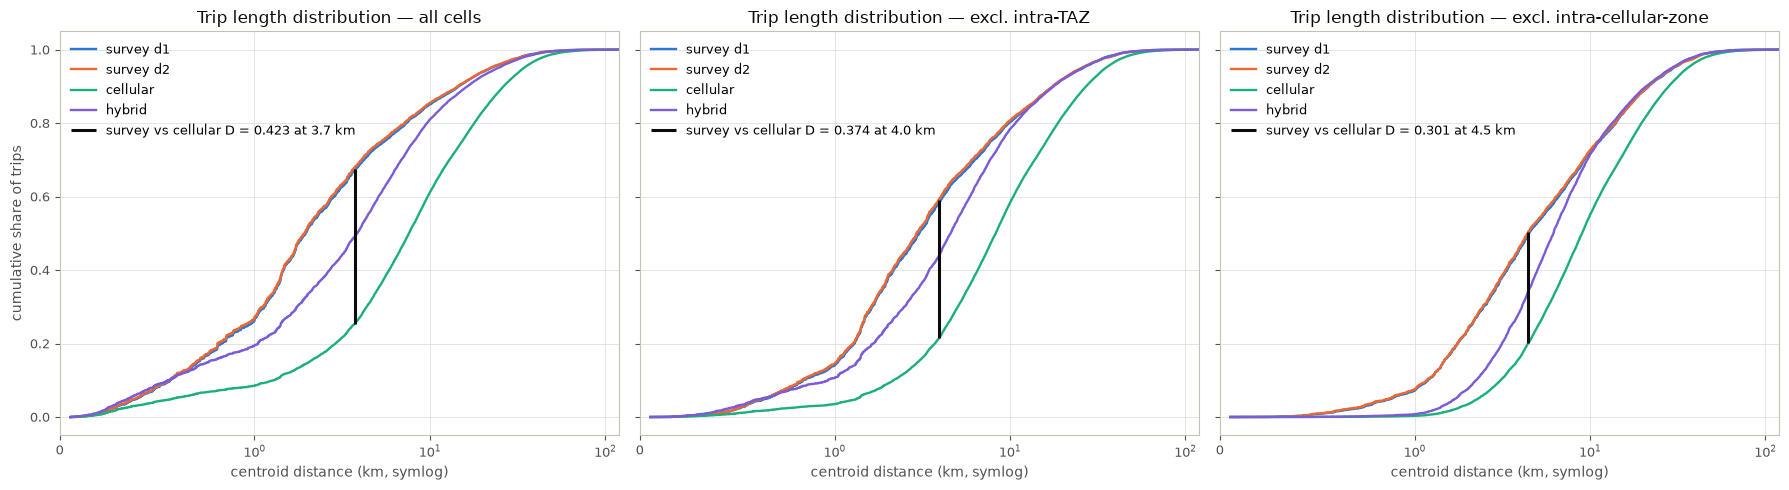

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white', sharey=True)
for ax, (mname, mask) in zip(axes, MASKS.items()):
    for name, color, ls in [('survey d1', BLUE, '-'), ('survey d2', ORANGE, '-'), ('cellular', AQUA, '-'), ('hybrid', PURPLE, '-')]:
        F = ecdf(SRC[name], mask)
        ax.plot(dist_sorted, F, color=color, linestyle=ls, linewidth=1.7, label=name)
    Fa, Fb = ecdf(SAVG, mask), ecdf(C, mask); D, x, sg = ks(Fa, Fb)
    ax.vlines(x, min(Fa[np.searchsorted(dist_sorted, x)], Fb[np.searchsorted(dist_sorted, x)]), max(Fa[np.searchsorted(dist_sorted, x)], Fb[np.searchsorted(dist_sorted, x)]),
              color=INK, linewidth=2.2, label=f'survey vs cellular D = {D:.3f} at {x:.1f} km')
    ax.set_xscale('symlog', linthresh=1); ax.set_xlim(0, 120)
    style_ax(ax, f'Trip length distribution — {mname}', 'centroid distance (km, symlog)', 'cumulative share of trips' if ax is axes[0] else None)
    ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout(); save_show(fig, 'ks_tld.png')

## KS3. Per-origin TLD at superzone level

Each origin superzone's trips (all its TAZ rows) as a distribution over distance. `D` per origin per pair, corridor superzones flagged.

In [9]:
rows = []
for z in SZ:
    mask = (sz_of == z)[:, None] & np.ones(N, dtype=bool)[None, :]
    F = {k: ecdf(v, mask) for k, v in SRC.items() if k != 'hybrid (GS-cal.)'}
    r = {'origin SZ': z, 'corridor': z in corr_sz, 'survey trips': SAVG[sz_of == z].sum(),
         'survey median km': wquantile(SAVG, .5, mask), 'cellular median km': wquantile(C, .5, mask), 'hybrid median km': wquantile(H, .5, mask)}
    for a, b in [('survey d1', 'survey d2'), ('survey avg', 'cellular'), ('hybrid', 'cellular'), ('hybrid', 'survey avg')]:
        D, x, sg = ks(F[a], F[b]); r[f'D {a} vs {b}'] = D; r[f'gap {a} vs {b}'] = sg
    rows.append(r)
ks3 = pd.DataFrame(rows)
ks3.to_csv(f'{OUT}/ks3_by_origin_sz.csv', index=False, float_format='%.4f')
w = ks3['survey trips'].values
print("flow-weighted mean D per origin superzone:")
for col in ['D survey d1 vs survey d2', 'D survey avg vs cellular', 'D hybrid vs cellular', 'D hybrid vs survey avg']:
    print(f"  {col:<28} {np.average(ks3[col], weights=w):.3f}   (corridor SZ only: {np.average(ks3.loc[ks3['corridor'], col], weights=w[ks3['corridor'].values]):.3f})")
ks3.sort_values('D survey avs cellular' if False else 'D survey avg vs cellular', ascending=False)[
    ['origin SZ', 'corridor', 'survey trips', 'survey median km', 'cellular median km', 'hybrid median km',
     'D survey d1 vs survey d2', 'D survey avg vs cellular', 'gap survey avg vs cellular', 'D hybrid vs cellular', 'D hybrid vs survey avg']].round(3)

flow-weighted mean D per origin superzone:
  D survey d1 vs survey d2     0.034   (corridor SZ only: 0.042)
  D survey avg vs cellular     0.450   (corridor SZ only: 0.467)
  D hybrid vs cellular         0.284   (corridor SZ only: 0.335)
  D hybrid vs survey avg       0.236   (corridor SZ only: 0.216)


,origin SZ,corridor,survey trips,survey median km,cellular median km,hybrid median km,D survey d1 vs survey d2,D survey avg vs cellular,gap survey avg vs cellular,D hybrid vs cellular,D hybrid vs survey avg
9,10,True,23433.065,1.537,13.112,2.307,0.016,0.722,0.722,0.673,0.256
25,30,False,50689.214,1.176,9.188,4.309,0.053,0.637,0.637,0.440,0.475
10,11,True,26725.511,0.836,8.313,2.551,0.034,0.632,0.632,0.482,0.331
20,21,True,49740.518,1.725,8.146,4.753,0.045,0.536,0.536,0.290,0.305
2,3,False,106561.721,1.479,7.738,3.487,0.033,0.515,0.515,0.322,0.295
34,39,False,103206.290,2.287,6.741,4.637,0.028,0.512,0.512,0.213,0.335
32,37,False,31457.043,1.538,8.158,5.551,0.042,0.504,0.504,0.278,0.362
26,31,False,39231.441,3.584,16.106,9.652,0.046,0.502,0.502,0.239,0.401
1,2,False,103799.481,2.019,9.401,5.089,0.016,0.495,0.495,0.280,0.273
29,34,False,73471.456,1.752,9.508,5.783,0.017,0.485,0.485,0.250,0.340


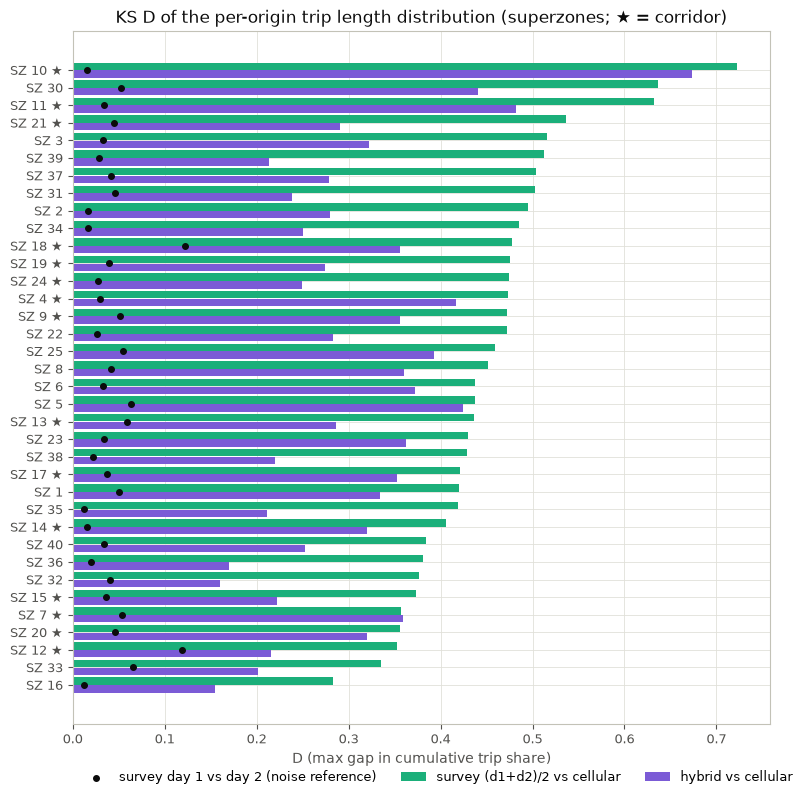

In [10]:
t = ks3.sort_values('D survey avg vs cellular')
fig, ax = plt.subplots(figsize=(9, 9), facecolor='white')
y = np.arange(len(t))
ax.barh(y + 0.22, t['D survey avg vs cellular'], height=0.42, color=AQUA, label='survey (d1+d2)/2 vs cellular')
ax.barh(y - 0.22, t['D hybrid vs cellular'], height=0.42, color=PURPLE, label='hybrid vs cellular')
ax.scatter(t['D survey d1 vs survey d2'], y, color=INK, s=16, zorder=3, label='survey day 1 vs day 2 (noise reference)')
ax.set_yticks(y); ax.set_yticklabels([f"SZ {int(z)}{' ★' if c else ''}" for z, c in zip(t['origin SZ'], t['corridor'])], fontsize=8)
style_ax(ax, 'KS D of the per-origin trip length distribution (superzones; ★ = corridor)', 'D (max gap in cumulative trip share)')
ax.legend(frameon=False, fontsize=9, loc='upper left', bbox_to_anchor=(0, -0.05), ncol=3)
save_show(fig, 'ks_by_origin.png')

## KS4. Corridor classes

In [11]:
cls = np.where(corridor[:, None] & corridor[None, :], 'corridor→corridor',
      np.where(corridor[:, None] & ~corridor[None, :], 'corridor→outside',
      np.where(~corridor[:, None] & corridor[None, :], 'outside→corridor', 'outside→outside')))
CLASSES = ['corridor→corridor', 'corridor→outside', 'outside→corridor', 'outside→outside']
rows = []
for k in CLASSES:
    mask = cls == k
    F = {n: ecdf(v, mask) for n, v in SRC.items() if n != 'hybrid (GS-cal.)'}
    for a, b in [('survey d1', 'survey d2'), ('survey avg', 'cellular'), ('hybrid', 'cellular'), ('hybrid', 'survey avg')]:
        D, x, sg = ks(F[a], F[b])
        rows.append({'class': k, 'pair': f'{a} vs {b}', 'D': D, 'at km': x, 'signed gap (A−B)': sg,
                     'A median km': wquantile(SRC[a], .5, mask), 'B median km': wquantile(SRC[b], .5, mask)})
ks4 = pd.DataFrame(rows)
ks4.to_csv(f'{OUT}/ks4_corridor_classes.csv', index=False, float_format='%.4f')
ks4.set_index(['class', 'pair']).round(3)

D   at km  signed gap (A−B)  \
class             pair                                                      
corridor→corridor survey d1 vs survey d2  0.017   6.590            -0.017   
                  survey avg vs cellular  0.387   2.630             0.387   
                  hybrid vs cellular      0.276   4.031             0.276   
                  hybrid vs survey avg    0.123   2.630            -0.123   
corridor→outside  survey d1 vs survey d2  0.037   6.880            -0.037   
                  survey avg vs cellular  0.282   4.067             0.282   
                  hybrid vs cellular      0.224   6.783             0.224   
                  hybrid vs survey avg    0.088   3.033            -0.088   
outside→corridor  survey d1 vs survey d2  0.024  19.772             0.024   
                  survey avg vs cellular  0.241   4.094             0.241   
                  hybrid vs cellular      0.179   5.296             0.179   
                  hybrid vs survey avg    0.086   2.900            -0.086   
outside→outside   survey d1 vs survey d2  0.010   3.375            -0.010   
                  survey avg vs cellular  0.432   3.732             0.432   
                  hybrid vs cellular      0.248   5.477             0.248   
                  hybrid vs survey avg    0.203   3.084            -0.203   

                                          A median km  B median km  
class             pair                                              
corridor→corridor survey d1 vs survey d2        1.071        0.999  
                  survey avg vs cellular        1.032        4.205  
                  hybrid vs cellular            1.577        4.205  
                  hybrid vs survey avg          1.577        1.032  
corridor→outside  survey d1 vs survey d2        4.339        4.216  
                  survey avg vs cellular        4.297        8.394  
                  hybrid vs cellular            4.980        8.394  
                  hybrid vs survey avg          4.980        4.297  
outside→corridor  survey d1 vs survey d2        5.200        5.160  
                  survey avg vs cellular        5.187        8.844  
                  hybrid vs cellular            5.850        8.844  
                  hybrid vs survey avg          5.850        5.187  
outside→outside   survey d1 vs survey d2        1.795        1.764  
                  survey avg vs cellular        1.782        7.641  
                  hybrid vs cellular            3.725        7.641  
                  hybrid vs survey avg          3.725        1.782

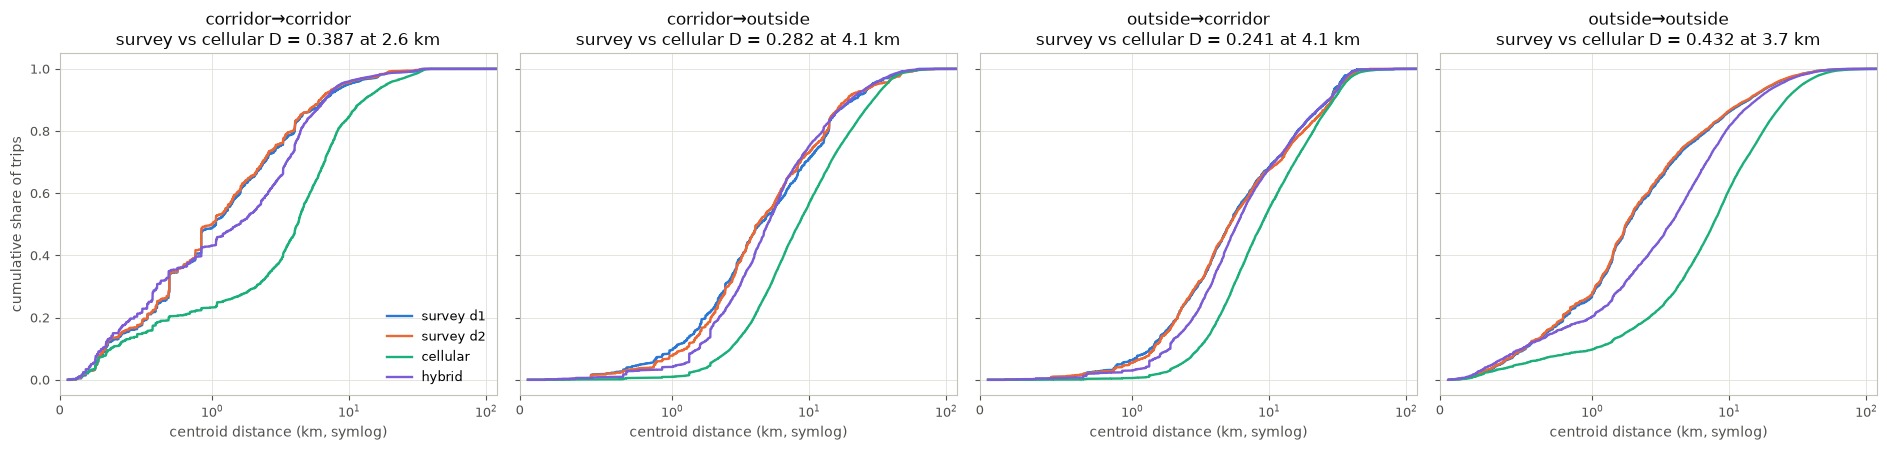

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6), facecolor='white', sharey=True)
for ax, k in zip(axes, CLASSES):
    mask = cls == k
    for name, color in [('survey d1', BLUE), ('survey d2', ORANGE), ('cellular', AQUA), ('hybrid', PURPLE)]:
        ax.plot(dist_sorted, ecdf(SRC[name], mask), color=color, linewidth=1.7, label=name)
    D = ks4[(ks4['class'] == k) & (ks4['pair'] == 'survey avg vs cellular')].iloc[0]
    ax.set_xscale('symlog', linthresh=1); ax.set_xlim(0, 120)
    style_ax(ax, f'{k}\nsurvey vs cellular D = {D["D"]:.3f} at {D["at km"]:.1f} km', 'centroid distance (km, symlog)', 'cumulative share of trips' if ax is axes[0] else None)
    if ax is axes[0]: ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout(); save_show(fig, 'ks_corridor.png')

## KS5. Flow concentration — how diffuse is each matrix?

Order the cells of a matrix by their own flow and cumulate trips: the curve `share of trips carried by cells with ≤ x trips/h`. A matrix whose trips sit in few big cells rises late; a diffuse one rises early. KS `D` between two matrices' curves, plus the share of trips in the top 1 % of cells and a Gini coefficient, at superzone and TAZ level. (Cellular is scaled to the survey total so cell sizes are comparable.)

In [13]:
def indicator(mapping):
    zones = sorted(set(mapping)); pos = {z: i for i, z in enumerate(zones)}
    M = np.zeros((N, len(zones)))
    for j, z in enumerate(mapping): M[j, pos[z]] = 1
    return M
M_sz = indicator(sz_of)

def conc_curve(X):
    v = np.sort(np.asarray(X, float).ravel() / 3.0)            # hourly cell flows, ascending
    return v, np.cumsum(v) / v.sum()

def conc_ks(A, B):
    va, Fa = conc_curve(A); vb, Fb = conc_curve(B)
    grid = np.unique(np.concatenate([va, vb]))
    FA = np.interp(grid, va, Fa, left=0); FB = np.interp(grid, vb, Fb, left=0)
    i = int(np.argmax(np.abs(FA - FB)))
    return float(abs(FA[i] - FB[i])), float(grid[i])

def gini(X):
    v = np.sort(np.asarray(X, float).ravel()); n = len(v)
    return float((2 * np.arange(1, n + 1) - n - 1) @ v / (n * v.sum()))

def top_share(X, q=0.01):
    v = np.sort(np.asarray(X, float).ravel())[::-1]; k = max(1, int(round(q * len(v))))
    return float(v[:k].sum() / v.sum())

rows, curves = [], {}
for lvl, M in [('SZ', M_sz), ('TAZ', np.eye(N))]:
    A = {k: M.T @ v @ M for k, v in SRC.items() if k != 'hybrid (GS-cal.)'}
    A['cellular'] = A['cellular'] * A['survey avg'].sum() / A['cellular'].sum()
    curves[lvl] = A
    for k, v in A.items():
        rows.append({'level': lvl, 'matrix': k, 'non-zero cells': int((v > 0).sum()), 'Gini': gini(v), 'share of trips in top 1% cells': top_share(v),
                     'share of trips in cells < 10/h': float(v[v / 3 < 10].sum() / v.sum())})
conc_stats = pd.DataFrame(rows); conc_stats.to_csv(f'{OUT}/ks5_concentration_stats.csv', index=False, float_format='%.4f')
rows = []
for lvl in ['SZ', 'TAZ']:
    A = curves[lvl]
    for a, b in [('survey d1', 'survey d2'), ('survey avg', 'cellular'), ('hybrid', 'cellular'), ('hybrid', 'survey avg')]:
        D, x = conc_ks(A[a], A[b]); rows.append({'level': lvl, 'pair': f'{a} vs {b}', 'D': D, 'at trips/h': x})
ks5 = pd.DataFrame(rows); ks5.to_csv(f'{OUT}/ks5_concentration.csv', index=False, float_format='%.4f')
print(conc_stats.round(3).to_string(index=False)); print()
ks5.set_index(['level', 'pair']).round(3)

level     matrix  non-zero cells  Gini  share of trips in top 1% cells  share of trips in cells < 10/h
   SZ  survey d1             738 0.919                           0.471                           0.000
   SZ  survey d2             730 0.921                           0.471                           0.000
   SZ survey avg             816 0.918                           0.471                           0.000
   SZ   cellular            1296 0.760                           0.244                           0.000
   SZ     hybrid            1296 0.914                           0.464                           0.001
  TAZ  survey d1           26049 0.990                           0.842                           0.089
  TAZ  survey d2           25997 0.990                           0.841                           0.092
  TAZ survey avg           33249 0.989                           0.824                           0.113
  TAZ   cellular          583588 0.843                           0.376   

D  at trips/h
level pair                                     
SZ    survey d1 vs survey d2  0.087   25570.747
      survey avg vs cellular  0.459   10526.568
      hybrid vs cellular      0.449   10526.568
      hybrid vs survey avg    0.078   24978.300
TAZ   survey d1 vs survey d2  0.028     387.153
      survey avg vs cellular  0.499      50.251
      hybrid vs cellular      0.310      39.181
      hybrid vs survey avg    0.252     207.965

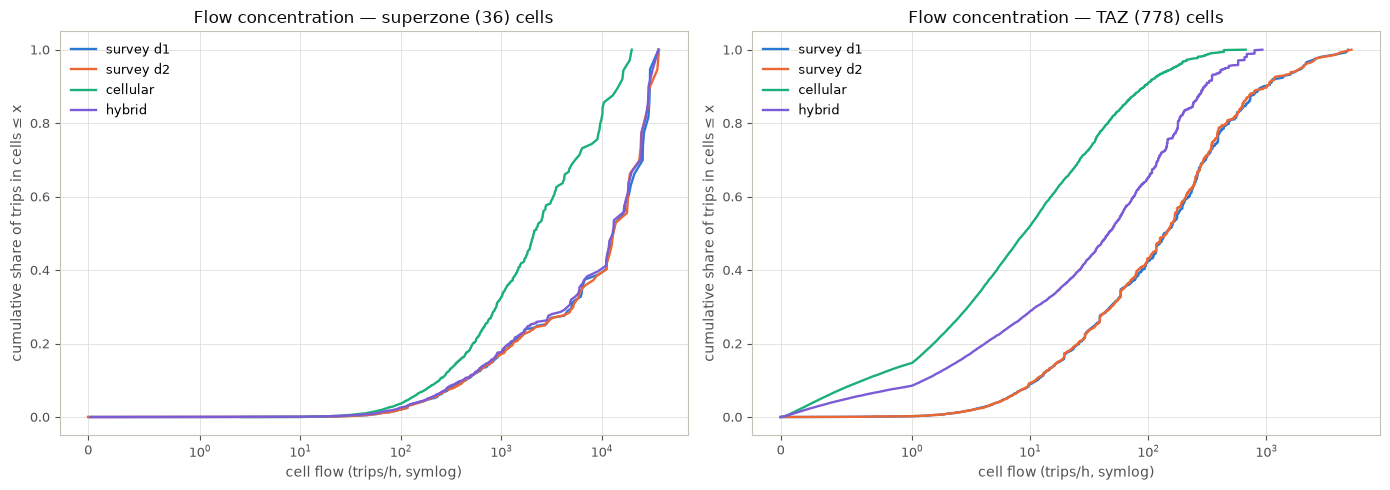

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
for ax, lvl in zip(axes, ['SZ', 'TAZ']):
    for name, color in [('survey d1', BLUE), ('survey d2', ORANGE), ('cellular', AQUA), ('hybrid', PURPLE)]:
        v, F = conc_curve(curves[lvl][name]); ax.plot(v, F, color=color, linewidth=1.7, label=name)
    ax.set_xscale('symlog', linthresh=1)
    style_ax(ax, f'Flow concentration — {"superzone (36)" if lvl == "SZ" else "TAZ (778)"} cells', 'cell flow (trips/h, symlog)', 'cumulative share of trips in cells ≤ x')
    ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout(); save_show(fig, 'ks_concentration.png')

## Summary

In [15]:
summ = ks1[ks1['pair'].isin(['survey d1 vs survey d2', 'survey avg vs cellular', 'hybrid vs cellular', 'hybrid vs survey avg'])].pivot(index='pair', columns='cells', values='D')
summ = summ.loc[['survey d1 vs survey d2', 'survey avg vs cellular', 'hybrid vs cellular', 'hybrid vs survey avg'], ['all cells', 'excl. intra-TAZ', 'excl. intra-cellular-zone']]
summ.columns = [f'TLD D ({c})' for c in summ.columns]
for lvl in ['SZ', 'TAZ']:
    summ[f'concentration D ({lvl})'] = ks5[ks5['level'] == lvl].set_index('pair')['D']
summ['per-origin TLD D, flow-wtd (SZ)'] = [np.average(ks3[f'D {p}'], weights=ks3['survey trips']) for p in summ.index]
summ.to_csv(f'{OUT}/ks_summary.csv', float_format='%.4f')
print(f"outputs written to {OUT}/ks*.csv and Output/figures/ks_*.png")
summ.round(3)

outputs written to Output/ths2017/tests/ks*.csv and Output/figures/ks_*.png


,TLD D (all cells),TLD D (excl. intra-TAZ),TLD D (excl. intra-cellular-zone),concentration D (SZ),concentration D (TAZ),"per-origin TLD D, flow-wtd (SZ)"
pair,,,,,,
survey d1 vs survey d2,0.009,0.011,0.009,0.087,0.028,0.034
survey avg vs cellular,0.423,0.374,0.301,0.459,0.499,0.450
hybrid vs cellular,0.249,0.242,0.179,0.449,0.310,0.284
hybrid vs survey avg,0.192,0.153,0.185,0.078,0.252,0.236


## Notes

- **Survey source.** Only the trips file (survey days 1 / 2) is read; the rebuilt day-average is asserted equal to the pipeline's saved matrix.
- **Distances** are straight-line centroid distances with a nearest-neighbour-based intra-TAZ proxy; KS0 quantifies what that proxy does to the survey's own reported lengths. Below the cellular zone, both survey and cellular TAZ patterns are cellular allocation shares, so intra-TAZ vs intra-zone contrasts (KS2) are the informative ones.
- **No classical p-values**: the expansion weights would make every comparison "significant". The day-1-vs-day-2 `D` and the household-bootstrap interval are the yardsticks; a `D` inside the bootstrap spread of the day-to-day comparison is noise.
- **KS is a distribution test**: it cannot see where in space trips go, only how far (KS1–4) or how concentrated the matrix is (KS5). The cosine / GEH notebook covers the spatial pattern.